# Range-separated dispersion vs. Q-Chem ALMO-EDA

The model is `rsfff.ff.dispersion.TTDispersion`: a Tang–Toennies damped $C_6$ backbone whose
per-atom coefficients come from environment-aware SOAP descriptors, plus a short-range
**pairwise** correction head, range-separated by a learnable Fermi switch.

$$E_\mathrm{disp} = \sum_{i<j}^{\text{inter}} \Big[\, S_\mathrm{Fermi}(r_{ij})\, T_\mathrm{cut}(r_{ij})\,
\big(-f_6(b_{ij} r_{ij})\, C_6^{ij} / r_{ij}^6\big) \;+\; W(r_{ij})\, \Delta E_{ij} \,\Big]$$

Trained on all 9597 EDA-labeled water clusters (w2–w5) against the `eda_disp` component.

**Caveat worth keeping in view:** `eda_disp` under ωB97X-V is the VV10 nonlocal-correlation
contribution to the *frozen* interaction, and `eda_mod_pauli` is *defined* as
`cls_pauli − disp`. The two are entangled by the decomposition, so the fitted $C_6$ is not a
transferable Casimir–Polder coefficient.

In [32]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path

# Resolve the repo root and work from there: every path below is repo-root-relative.
# Both steps are absolute and idempotent -- a relative sys.path entry like "../scripts"
# would be resolved at *import* time, i.e. after the chdir, and would miss.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np
import torch

import dispersion_plots as dp
from dispersion_analysis import (
    CLUSTERS, load_model, load_clusters, predict, atom_parameters,
    many_body_table, strongest_frames,
)

dp.use_style()

model, cfg, state = load_model(
    "checkpoints/eda_water_disp/best.pt", "configs/eda_water_disp_full.yaml"
)
datasets = load_clusters()

print(f"working from {ROOT}")
print(f"checkpoint from epoch {state['epoch']}, val loss {state['val_loss']:.4f}")
print(f"learned range separation r0 = {float(model.r0.detach()):.3f} A "
      f"(started at {cfg.dispersion.r0_init})")
print({tag: len(ds) for tag, ds in datasets.items()})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
working from /Users/joseph.heindel/dev/rsfff
checkpoint from epoch 51, val loss 0.0809
learned range separation r0 = 1.481 A (started at 2.0)
{'w2': 2401, 'w3': 2400, 'w4': 2400, 'w5': 2396}


## 1. Accuracy

`corr_fraction` is $|E_\mathrm{corr}| / (|E_\mathrm{FF}| + |E_\mathrm{corr}|)$ — the share of the
pair energy the neural head supplied. It starts at exactly 0 (the head is zero-initialized,
so training begins as the pure force field) and the $r_0$ penalty pushes against it growing.

In [33]:
preds = {tag: predict(model, datasets[tag], tag) for tag in CLUSTERS}

print(f"{'cluster':<9}{'n':<7}{'MAE':<9}{'RMSE':<9}{'R^2':<10}{'<corr frac>':<12}")
for tag, p in preds.items():
    print(f"{tag:<9}{len(p.ref):<7}{p.mae:<9.4f}{p.rmse:<9.4f}{p.r2:<10.5f}"
          f"{p.corr_fraction.mean():<12.4f}")

err = np.concatenate([p.error for p in preds.values()])
print(f"\noverall MAE {np.abs(err).mean():.4f} kJ/mol over {len(err)} frames")

cluster  n      MAE      RMSE     R^2       <corr frac> 
w2       2401   0.0451   0.0613   0.99968   0.0121      
w3       2400   0.0519   0.0684   0.99976   0.0063      
w4       2400   0.0686   0.0879   0.99975   0.0055      
w5       2396   0.0883   0.1130   0.99972   0.0052      

overall MAE 0.0635 kJ/mol over 9597 frames


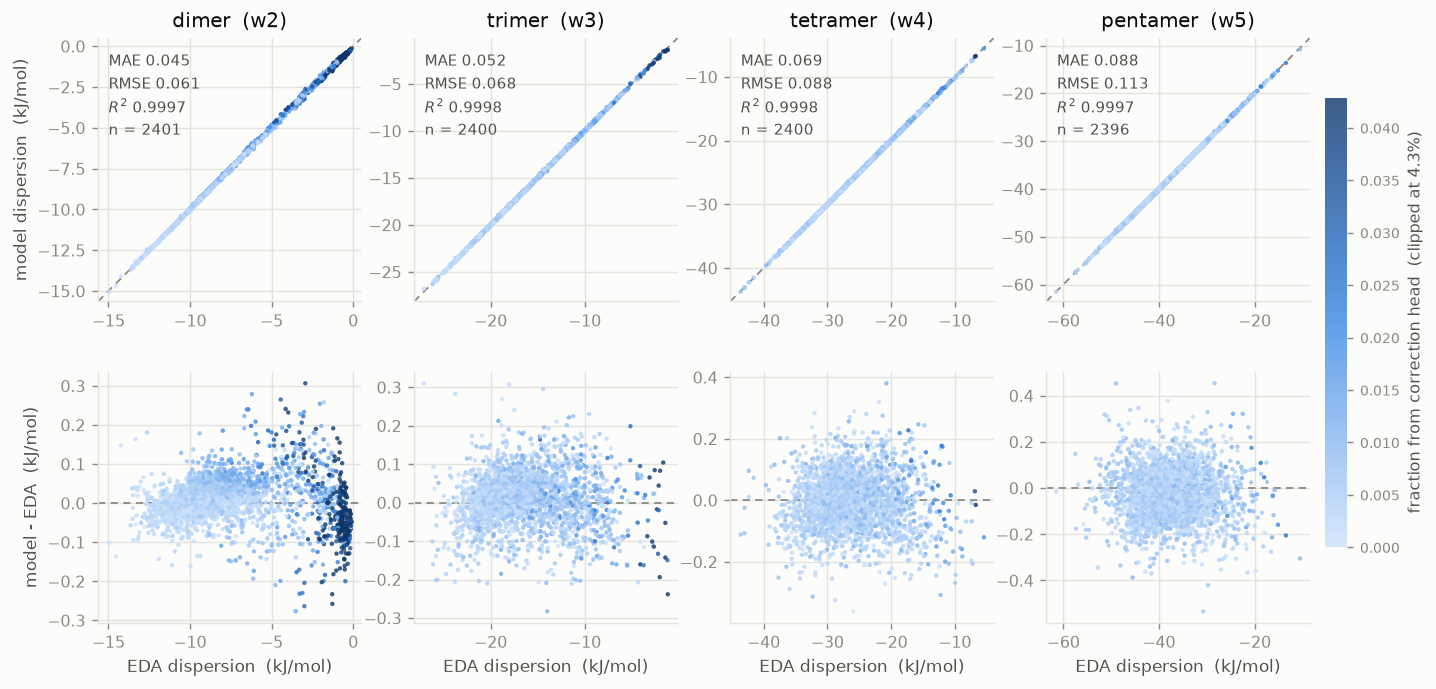

In [34]:
fig = dp.correlation_panels(preds, path="notebooks/figures/disp_correlation.png")

## 2. The learned effective dispersion coefficients

This is the payoff of letting the descriptors see the environment: $C_6$ is no longer a
per-element constant but an **effective** coefficient that responds to what surrounds the atom.
The dashed line is the per-species value the environment MLP modulates around.

In [35]:
records = {k: np.concatenate([
    atom_parameters(model, datasets[t], n_frames=150)[0][k] for t in CLUSTERS
]) for k in ("Z", "c6", "b", "n_fragments", "contact")}
_, priors = atom_parameters(model, datasets["w2"], n_frames=1)

for z, sym in ((1, "H"), (8, "O")):
    m = records["Z"] == z
    c6, b = records["c6"][m], records["b"][m]
    print(f"{sym}:  C6 = {c6.mean():7.3f} +/- {c6.std():.3f}  "
          f"[{c6.min():.3f}, {c6.max():.3f}]   prior {priors[z][0]:.3f}")
    print(f"    b  = {b.mean():7.3f} +/- {b.std():.3f}  "
          f"[{b.min():.3f}, {b.max():.3f}]   prior {priors[z][1]:.3f}")

H:  C6 =   0.776 +/- 0.210  [0.306, 1.116]   prior 1.990
    b  =   1.935 +/- 0.000  [1.935, 1.935]   prior 2.000
O:  C6 =  43.573 +/- 1.643  [36.769, 46.960]   prior 35.829
    b  =   1.989 +/- 0.000  [1.989, 1.989]   prior 2.000


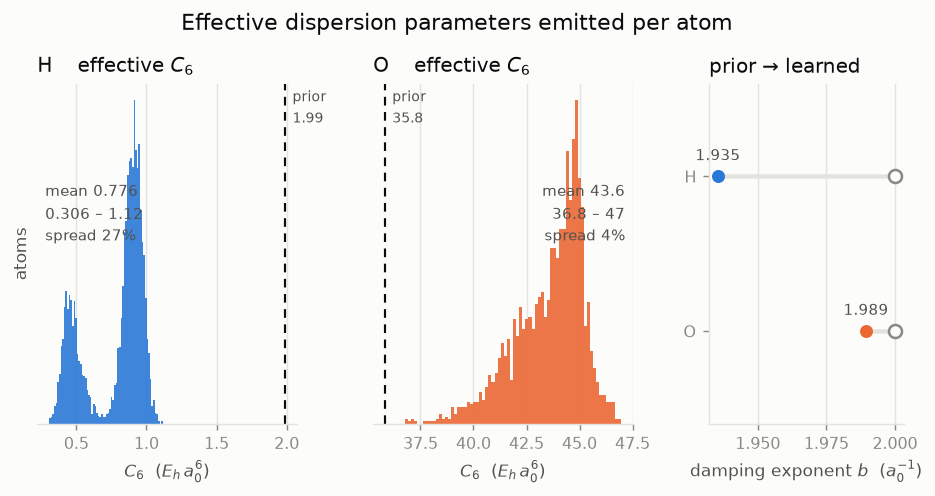

In [36]:
fig = dp.parameter_panels(records, priors, path="notebooks/figures/disp_parameters.png")

Hydrogen's distribution comes out **bimodal**. Cluster size turns out not to explain it — the
medians barely move from dimer to pentamer. What does explain it is *local* engagement: the
distance from each atom to the nearest atom in another molecule, which for a hydrogen separates
H-bond donors (~1.8 Å to the acceptor oxygen) from free OH hydrogens.

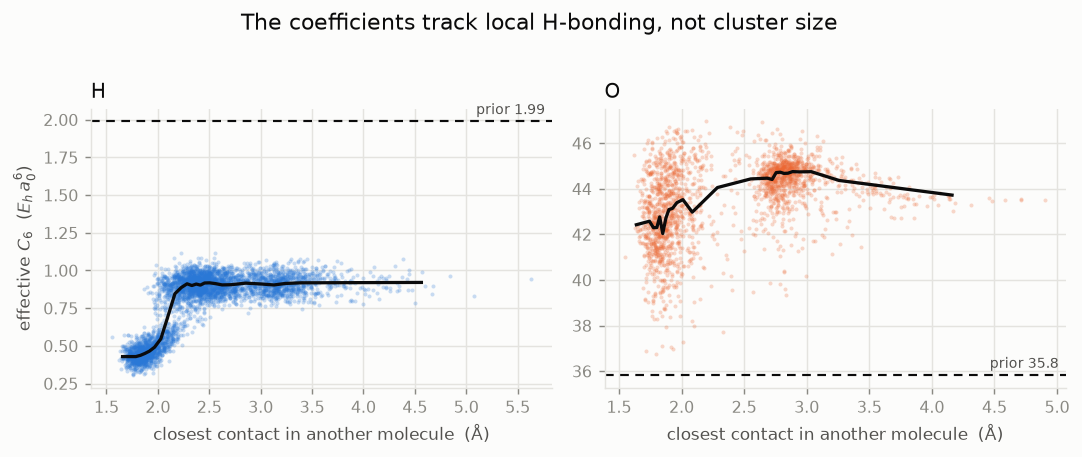

In [37]:
fig = dp.parameter_vs_environment(
    records, priors, path="notebooks/figures/disp_parameters_env.png"
)

## 3. Many-body expansion

For a cluster of $N$ molecules the interaction decomposes exactly as

$$E(1\ldots N) = \sum_k E^{(k)}, \qquad
E^{(k)} = \sum_{|S| = k} \sum_{T \subseteq S} (-1)^{|S| - |T|} E(T)$$

Each subset is evaluated **with only that subset present**, so the descriptors see exactly the
sub-cluster. A pair sum with per-element coefficients is strictly additive and every
$E^{(k \geq 3)}$ vanishes identically — `tests/test_many_body.py` asserts precisely that, which
is what makes a nonzero value here meaningful rather than a bug.

We take the 167 most strongly interacting frames of each of w3/w4/w5 (~500 clusters),
ranked by total EDA interaction energy.

In [38]:
mbe = many_body_table(model, datasets, per_cluster=167)

print(f"{'cluster':<9}{'n':<6}{'total':<10}{'2-body':<10}{'3-body':<10}"
      f"{'4-body':<10}{'5-body':<10}{'|MB|/|tot|':<10}")
for tag in ("w3", "w4", "w5"):
    m = mbe["tag"] == tag
    print(f"{tag:<9}{m.sum():<6}{mbe['total'][m].mean():<10.3f}"
          f"{mbe['two_body'][m].mean():<10.3f}{mbe['e3'][m].mean():<10.3f}"
          f"{mbe['e4'][m].mean():<10.3f}{mbe['e5'][m].mean():<10.3f}"
          f"{np.abs(mbe['many_body'][m] / mbe['total'][m]).mean() * 100:<10.2f}")

print(f"\nnon-additivity from effective C6:      {mbe['mb_ff'].mean():+.4f} kJ/mol")
print(f"non-additivity from correction head:   {mbe['mb_corr'].mean():+.4f} kJ/mol")

cluster  n     total     2-body    3-body    4-body    5-body    |MB|/|tot|
w3       167   -17.891   -18.039   0.147     0.000     0.000     0.79      
w4       167   -29.006   -29.429   0.449     -0.025    0.000     1.38      
w5       167   -41.301   -42.069   0.865     -0.137    0.040     1.77      

non-additivity from effective C6:      +0.5632 kJ/mol
non-additivity from correction head:   -0.1170 kJ/mol


### Is the many-body content *right*?

There is no reference many-body dispersion in this dataset — that would need EDA calculations
on every sub-cluster. But there is one indirect handle worth taking seriously.

The model's 2-body sum is built purely from **isolated dimer** evaluations, and dimers are
exactly where we do have direct reference data: 2401 w2 frames, fit to 0.045 kJ/mol. So
`reference − model 2-body` is a reasonable proxy for the *true* many-body dispersion of each
cluster. Comparing it against the model's own many-body terms is the closest thing to a
validation available.

Read the result with the caveat that it is **not fully independent**: the model was trained on
the w3/w4/w5 totals, so it is partly guaranteed to fit them. What is *not* guaranteed is that
the required correction has the right size and grows the right way with cluster size — and it
does, from ~0.13 kJ/mol at trimers to ~0.79 at pentamers.

In [39]:
print(f"{'cluster':<9}{'MAE full':<11}{'MAE 2-body':<13}{'model MB':<12}{'reference asks':<15}")
for tag in ("w3", "w4", "w5"):
    m = mbe["tag"] == tag
    full = np.abs(mbe["total"][m] - mbe["ref"][m]).mean()
    two = np.abs(mbe["two_body"][m] - mbe["ref"][m]).mean()
    print(f"{tag:<9}{full:<11.4f}{two:<13.4f}"
          f"{(mbe['total'][m] - mbe['two_body'][m]).mean():<+12.4f}"
          f"{(mbe['ref'][m] - mbe['two_body'][m]).mean():<+15.4f}")

model_mb = mbe["total"] - mbe["two_body"]
needed_mb = mbe["ref"] - mbe["two_body"]
print(f"\nmodel many-body vs (reference - model 2-body): "
      f"r = {np.corrcoef(model_mb, needed_mb)[0, 1]:.4f}, "
      f"slope = {np.polyfit(model_mb, needed_mb, 1)[0]:.3f}")

cluster  MAE full   MAE 2-body   model MB    reference asks 
w3       0.0417     0.1387       +0.1474     +0.1312        
w4       0.0547     0.4227       +0.4235     +0.4217        
w5       0.0783     0.7859       +0.7675     +0.7859        

model many-body vs (reference - model 2-body): r = 0.9867, slope = 1.012


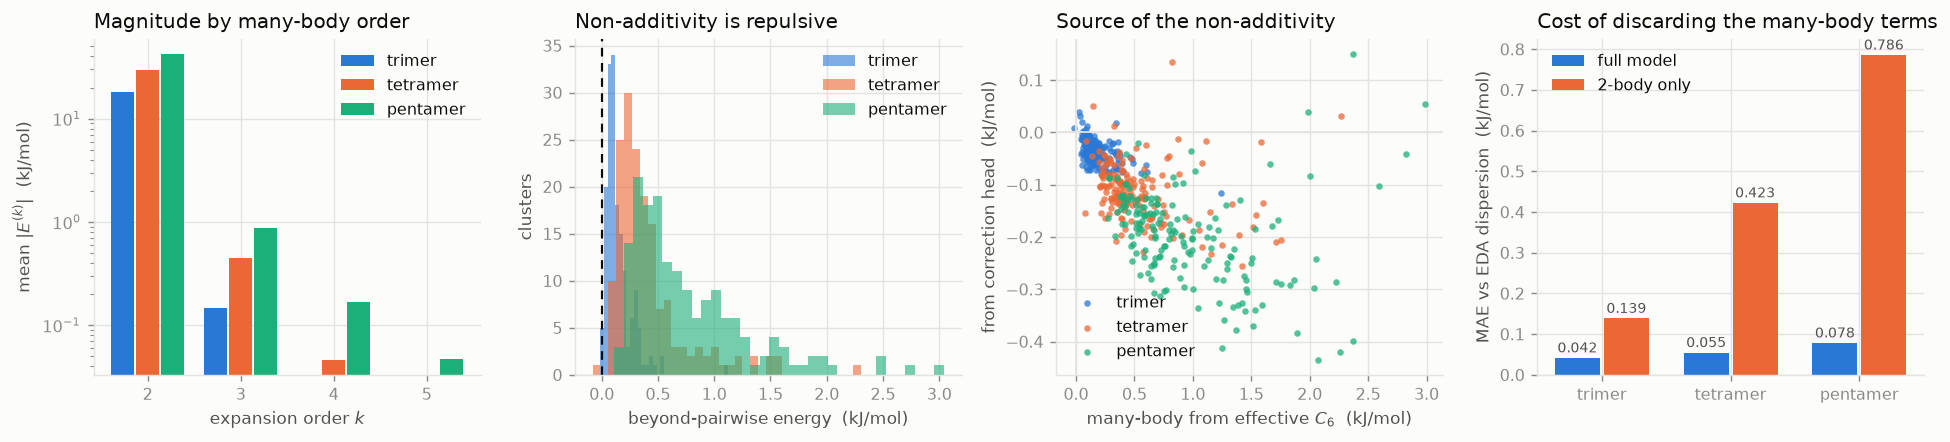

In [40]:
fig = dp.many_body_panels(mbe, path="notebooks/figures/disp_many_body.png")

### Does the non-additivity actually buy anything?

The many-body content above is exact *for the model*, but the dataset has **no reference
many-body dispersion** — that would need EDA calculations on every sub-cluster, which we don't
have. So we test it indirectly, with two controls:

| variant | flexibility | many-body |
|---|---|---|
| **environment-aware** (full) | environment $C_6$ + correction head | yes |
| **intra-fragment** | *identical capacity*, descriptors grouped by fragment | **zero, by construction** |
| **per-species only** | rigid $C_6$/$b$, no correction head | zero |

The **intra-fragment** row is the control that matters. It keeps every parameter the full model
has and only changes what each atom is allowed to *see*, so its pair sum is strictly additive
(asserted in `tests/test_many_body.py::test_intra_fragment_features_are_additive`) while its
capacity is unchanged. Any gap between it and the full model is many-body content and nothing
else.

The per-species row is a weaker control: it removes flexibility *and* non-additivity at once,
so on dimers — where many-body is zero by definition — its gap measures flexibility alone.
Reading that gap as "many-body" would be a mistake.

In [41]:
variants = {"environment-aware (full)": preds}
for label, run in (
    ("intra-fragment (additive, same capacity)", "intra"),
    ("per-species only (additive, rigid)", "additive"),
):
    m, _, s = load_model(
        f"checkpoints/eda_water_disp_{run}/best.pt",
        f"configs/eda_water_disp_{run}.yaml",
    )
    variants[label] = {tag: predict(m, datasets[tag], tag) for tag in CLUSTERS}

print(f"{'variant':<44}" + "".join(f"{t:<10}" for t in CLUSTERS))
for label, p in variants.items():
    print(f"{label:<44}" + "".join(f"{p[t].mae:<10.4f}" for t in CLUSTERS))

intra = variants["intra-fragment (additive, same capacity)"]
print("\nmany-body gain (full vs additive-of-equal-capacity):")
for tag in CLUSTERS:
    print(f"  {tag}: {intra[tag].mae:.4f} -> {preds[tag].mae:.4f} kJ/mol "
          f"({intra[tag].mae / preds[tag].mae:.2f}x)")

variant                                     w2        w3        w4        w5        
environment-aware (full)                    0.0451    0.0519    0.0686    0.0883    
intra-fragment (additive, same capacity)    0.2107    0.2942    0.3408    0.3985    
per-species only (additive, rigid)          0.2573    0.3631    0.4352    0.5590    

many-body gain (full vs additive-of-equal-capacity):
  w2: 0.2107 -> 0.0451 kJ/mol (4.67x)
  w3: 0.2942 -> 0.0519 kJ/mol (5.66x)
  w4: 0.3408 -> 0.0686 kJ/mol (4.96x)
  w5: 0.3985 -> 0.0883 kJ/mol (4.51x)


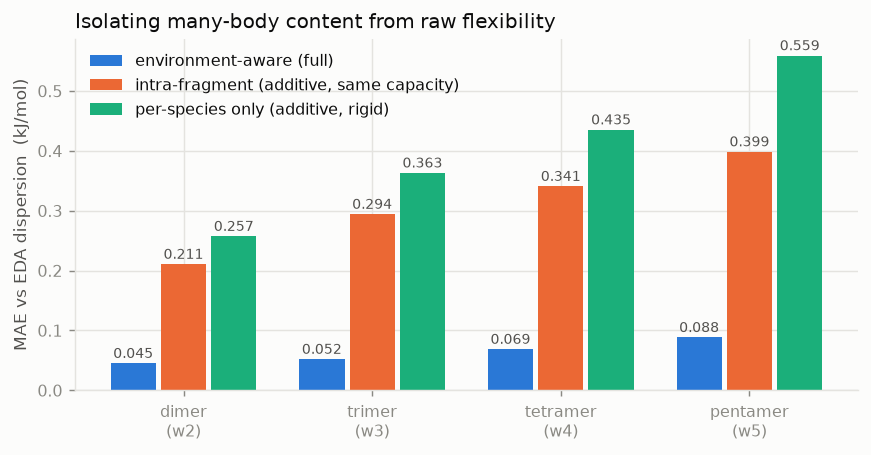

In [42]:
fig = dp.additive_comparison(
    variants, path="notebooks/figures/disp_additive_control.png"
)

## 4. Scratch space

`mbe` is a dict of flat numpy arrays (`tag`, `n_fragments`, `total`, `two_body`, `many_body`,
`e3`/`e4`/`e5`, `mb_ff`, `mb_corr`, `ref`), and `preds[tag]` carries `pred`/`ref`/`ff`/`corr`
per frame — all in kJ/mol. `rsfff.ff.many_body.mbe_decompose` runs a single cluster if you
want to look at one in detail.

In [43]:
# one pentamer, in full
from rsfff.ff.many_body import mbe_decompose
from rsfff.ff.units import KJMOL_PER_HARTREE as K

idx = strongest_frames(datasets["w5"], 1)[0]
frame = datasets["w5"].flat_batch([idx])
res = mbe_decompose(model, frame.positions, frame.atomic_numbers, frame.fragment_idx)

print(f"reference eda_disp {float(frame.eda['disp']) * K:8.3f} kJ/mol")
print(f"model total        {float(res.total) * K:8.3f} kJ/mol")
for k, v in res.by_order.items():
    print(f"  {k}-body          {float(v) * K:8.3f}")

reference eda_disp  -55.045 kJ/mol
model total         -55.117 kJ/mol
  2-body           -56.088
  3-body             1.138
  4-body            -0.310
  5-body             0.143


---

# Part 2 — Pauli repulsion vs. Q-Chem ALMO-EDA

The model is `rsfff.ff.pauli.SlaterPauli`: the **Slater two-center damping** applied to the
multipole interaction tensor, with the undamped tail subtracted off so the term is
exponentially short-ranged by construction, plus its own term-specific pair correction.

$$E_\mathrm{Pauli} = \sum_{i<j}^{\text{inter}} \Big[\, T_\mathrm{cut}(r_{ij})\;
\mathbf{m}_j^{\mathsf T}\, \big[f_n(b_{ij} r_{ij})\, \mathbf{T}(\mathbf{r}_{ij})\big]\, \mathbf{m}_i
\;+\; W(r_{ij})\, \Delta E_{ij} \,\Big]$$

Unlike dispersion there is **no Fermi range separation**: the Slater form is valid all the
way in, so nothing has to be handed to the network at a midpoint.

The parameter function emits the Pauli multipoles $\mathbf{m}_i = [q_i, \boldsymbol{\mu}_i,
\mathbf{\Theta}_i]$ *directly* — a departure from pyCMM, which scales the real
electrostatic multipoles by fitted $K_\mathrm{dipo}$/$K_\mathrm{quad}$ factors. The dipole
comes from the $\lambda=1$ (odd-parity) features and the quadrupole from $\lambda=2$,
predicted as its five **spherical** components $(q_{20}, q_{21c}, q_{21s}, q_{22c}, q_{22s})$
and converted to Cartesian for the contraction. Five rather than six is structural: the
traceless constraint is then exact, where a six-component Cartesian prediction would carry
an isotropic degree of freedom the interaction tensor cannot see.

Target is `eda_mod_pauli` = `cls_pauli − disp`, so it composes with Part 1 with no double
counting.

In [44]:
import pauli_plots as pp
from pauli_analysis import load_model as load_pauli, predict as predict_pauli, atom_parameters as pauli_params
from rsfff.ff.pauli import DEFAULT_PAULI_PRIOR

PAULI_RUNS = [
    ("rank 2 (+quadrupoles)", "checkpoints/eda_water_pauli_q/best.pt", "configs/eda_water_pauli_quad.yaml"),
    ("rank 1 (charges + dipoles)", "checkpoints/eda_water_pauli/best.pt", "configs/eda_water_pauli.yaml"),
    ("rank 1, intra-fragment features", "checkpoints/eda_water_pauli_intra/best.pt", "configs/eda_water_pauli_intra.yaml"),
]

pauli_model, pauli_cfg, pauli_state = load_pauli(*PAULI_RUNS[0][1:])
print(f"{PAULI_RUNS[0][0]}: epoch {pauli_state['epoch']}  val_loss {pauli_state['val_loss']:.4f}")
pauli_preds = {tag: predict_pauli(pauli_model, ds, pauli_cfg.pauli.target) for tag, ds in datasets.items()}

print(f"{'cluster':<9}{'MAE':<9}{'RMSE':<9}{'R^2':<10}{'corr share'}")
for tag, p in pauli_preds.items():
    err = p["pred"] - p["ref"]
    share = np.abs(p["corr"]) / np.maximum(np.abs(p["ff"]) + np.abs(p["corr"]), 1e-30)
    print(f"{tag:<9}{np.abs(err).mean():<9.4f}{np.sqrt((err**2).mean()):<9.4f}"
          f"{np.corrcoef(p['pred'], p['ref'])[0,1]**2:<10.5f}{share.mean()*100:.2f}%")

rank 2 (+quadrupoles): epoch 37  val_loss 0.1728
cluster  MAE      RMSE     R^2       corr share
w2       0.1394   0.2069   0.99993   2.08%
w3       0.2363   0.3292   0.99991   0.29%
w4       0.3397   0.4421   0.99991   0.21%
w5       0.4588   0.5879   0.99990   0.20%


## Correlation, colored by how much came from the correction head

Same convention as Part 1: the residual row exists because at $R^2 > 0.999$ the parity plot
alone shows nothing. Color is the share of the pair energy the network supplied — a nearly
white cloud means the Slater backbone is carrying the physics and the correction really is a
delta.

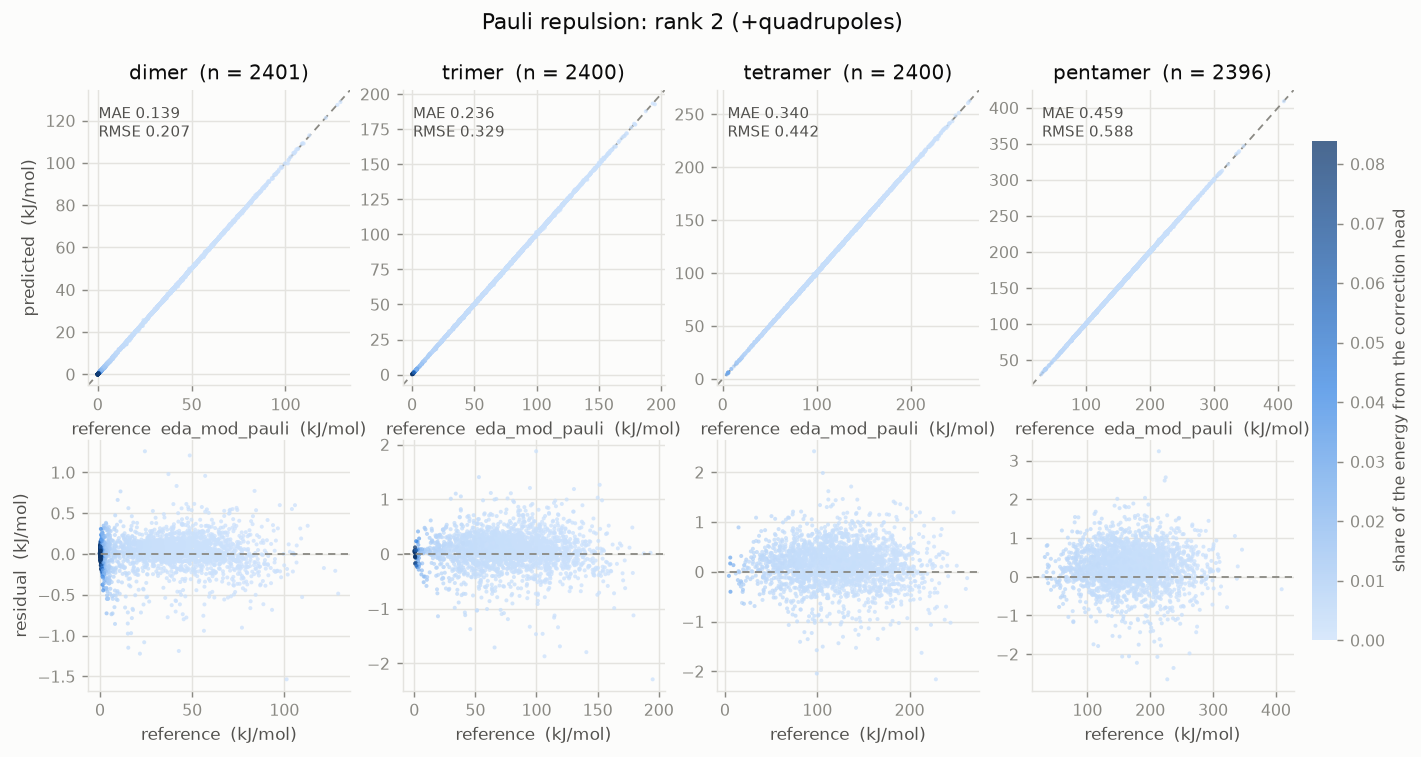

In [45]:
_ = pp.correlation_panels(pauli_preds, title=f"Pauli repulsion: {PAULI_RUNS[0][0]}")

## The learned Pauli multipoles

Charge and damping exponent are shown against pyCMM's fitted priors; the interesting
statement is the *displacement* from a fitted classical model. The dipole and quadrupole
panels have no prior marker because those heads are zero-initialized — the reference is the
origin, and any nonzero width is something the fit decided it needed.

H: q   0.492 (prior 0.528)   b 1.993 (prior 1.965)   |mu| 0.0399   |Q| 0.0338
O: q   6.110 (prior 6.509)   b 2.174 (prior 2.197)   |mu| 0.1815   |Q| 1.3550


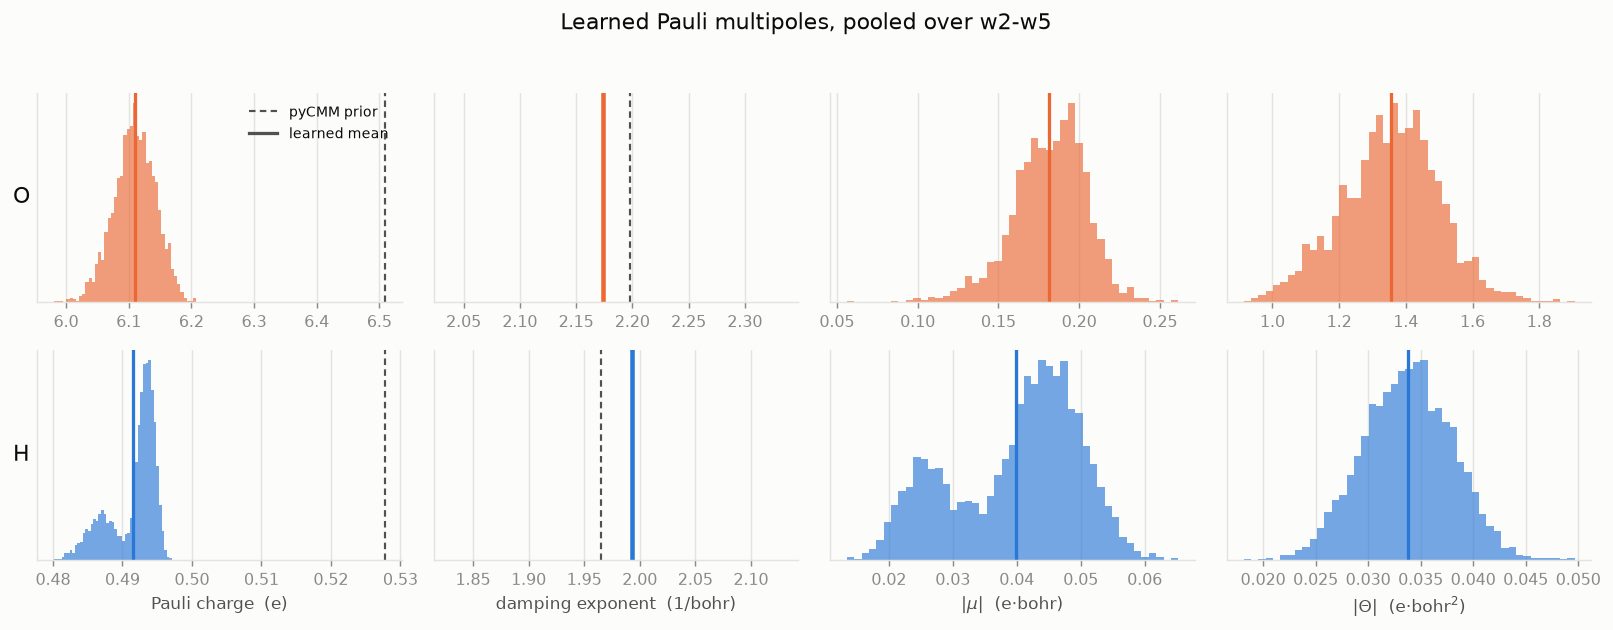

In [46]:
pauli_atoms = pauli_params(pauli_model, datasets, n_frames=150, target=pauli_cfg.pauli.target)
_ = pp.parameter_panels(pauli_atoms, DEFAULT_PAULI_PRIOR)

for z, sym in ((1, "H"), (8, "O")):
    m = pauli_atoms["Z"] == z
    print(f"{sym}: q {pauli_atoms['q'][m].mean():7.3f} (prior {DEFAULT_PAULI_PRIOR[z][0]:.3f})"
          f"   b {pauli_atoms['b'][m].mean():5.3f} (prior {DEFAULT_PAULI_PRIOR[z][1]:.3f})"
          f"   |mu| {pauli_atoms['mu'][m].mean():.4f}   |Q| {pauli_atoms['quad'][m].mean():.4f}")

## What each rank of the multipole expansion buys

The rank ladder is a strict nesting: both equivariant heads are zero-initialized, so rank 2
reproduces rank 1 exactly at initialization and any gain is real. The intra-fragment run is
the additive control — parameters that see only their own monomer.

variant                           w2        w3        w4        w5        
rank 2 (+quadrupoles)             0.1394    0.2363    0.3397    0.4588    
rank 1 (charges + dipoles)        0.1811    0.2784    0.3723    0.4738    
rank 1, intra-fragment features   0.6812    1.1028    1.4683    1.7572    


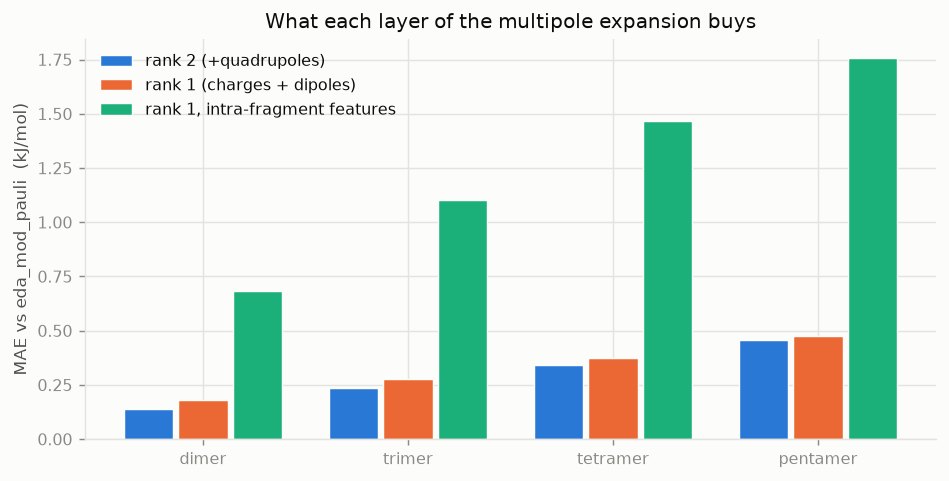

In [47]:
pauli_table = {}
for label, ckpt, conf in PAULI_RUNS:
    if not Path(ckpt).exists():
        print(f"skipping '{label}': not trained")
        continue
    m, c, s = load_pauli(ckpt, conf)
    pr = {tag: predict_pauli(m, ds, c.pauli.target) for tag, ds in datasets.items()}
    pauli_table[label] = {t: float(np.abs(p["pred"] - p["ref"]).mean()) for t, p in pr.items()}

_ = pp.rank_comparison(pauli_table)
print(f"{'variant':<34}" + "".join(f"{t:<10}" for t in CLUSTERS))
for label, row in pauli_table.items():
    print(f"{label:<34}" + "".join(f"{row[t]:<10.4f}" for t in CLUSTERS))

## Range separation vs. the delta-learning cutoff

Every term carries **two independent distance scales**, and they are set in completely
different ways:

- where the *physics* hands over — dispersion's Fermi midpoint $r_0$, **learned** under a
  penalty pushing it down;
- where the *network* is allowed to contribute — the pair head's compact envelope
  $[r_\mathrm{on}, r_\mathrm{off}]$, a **fixed hyperparameter**.

Nothing in the training loop forces those to agree. The shaded band below is the region
where the full analytic term and the correction are *both* at full strength — the place a
systematic backbone error can hide inside the network instead of showing up as a fit error.
The bottom two panels say whether that band matters: how many pairs live there, and how much
of each piece's energy it accounts for.

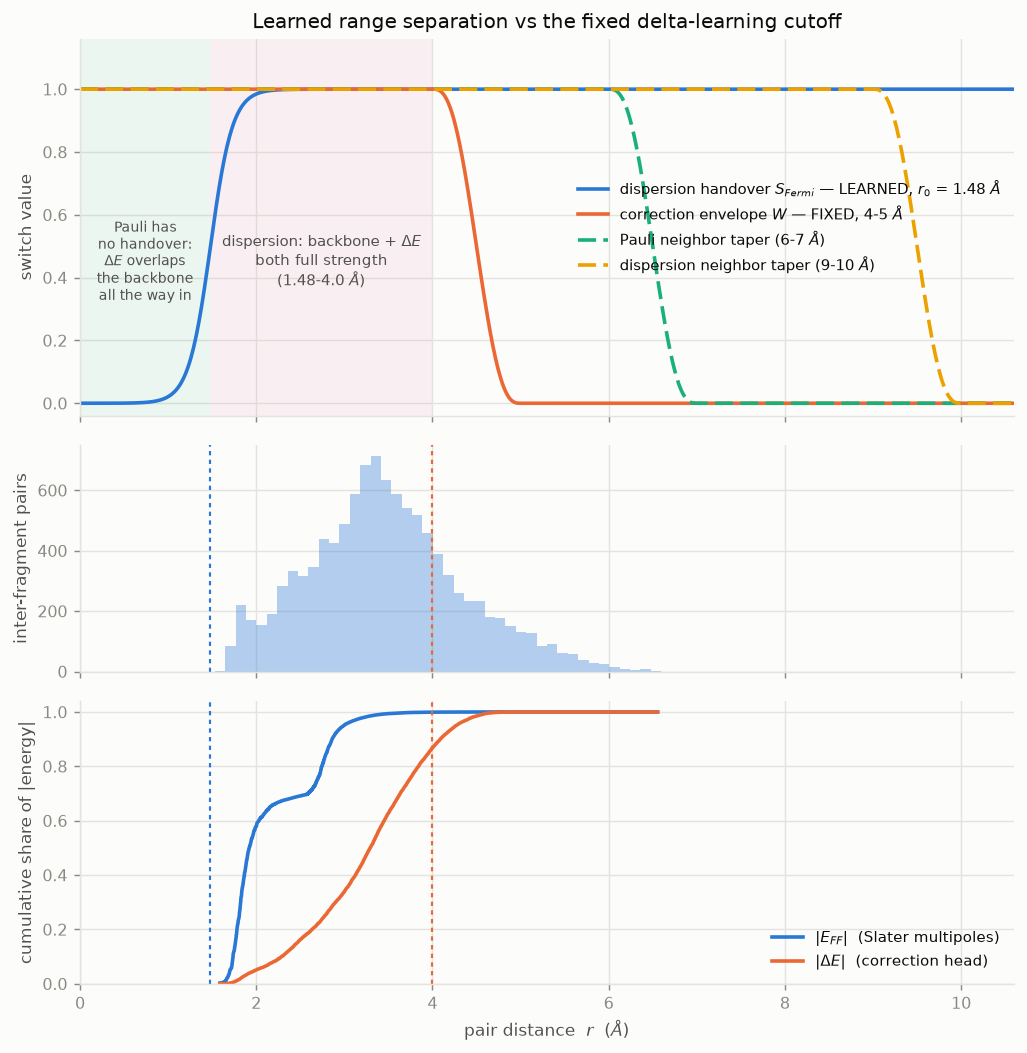

In [48]:
pair = predict_pauli(pauli_model, datasets["w3"], pauli_cfg.pauli.target,
                     n_frames=400, with_pairs=True)
disp_r0 = float(model.r0.detach())

_ = pp.switching_functions(
    pair["pair_r"], pair["pair_e_ff"], pair["pair_e_corr"],
    disp_r0=disp_r0,
    corr_window=(pauli_cfg.pauli.corr_r_on, pauli_cfg.pauli.corr_r_off),
    taper_window=(pauli_cfg.pauli.cutoff - pauli_cfg.pauli.taper_width, pauli_cfg.pauli.cutoff),
)

In [49]:
r = pair["pair_r"]; ff = np.abs(pair["pair_e_ff"]); corr = np.abs(pair["pair_e_corr"])
r_on = pauli_cfg.pauli.corr_r_on

print(f"dispersion learned Fermi midpoint r0 = {disp_r0:.3f} A")
print(f"correction envelope                  = {r_on:.1f}-{pauli_cfg.pauli.corr_r_off:.1f} A (fixed)")
print(f"band where both are at full strength = {disp_r0:.2f}-{r_on:.1f} A ({r_on - disp_r0:.2f} A wide)")

inside = (r >= disp_r0) & (r <= r_on)
print(f"  {inside.mean()*100:.1f}% of inter-fragment pairs sit in that band,"
      f" carrying {ff[inside].sum()/ff.sum()*100:.1f}% of |E_FF|"
      f" and {corr[inside].sum()/max(corr.sum(),1e-30)*100:.1f}% of |dE|")

order = np.argsort(r)
for name, mag in (("|E_FF|", ff), ("|dE|", corr)):
    if mag.sum() <= 0:
        continue
    c = np.cumsum(mag[order]) / mag.sum()
    pts = ", ".join(f"{f:.0%} by {r[order][np.searchsorted(c, f)]:.2f} A" for f in (0.5, 0.9, 0.99))
    print(f"  {name:>7}: {pts}")

dispersion learned Fermi midpoint r0 = 1.481 A
correction envelope                  = 4.0-5.0 A (fixed)
band where both are at full strength = 1.48-4.0 A (2.52 A wide)
  75.5% of inter-fragment pairs sit in that band, carrying 99.9% of |E_FF| and 86.8% of |dE|
   |E_FF|: 50% by 1.92 A, 90% by 2.86 A, 99% by 3.38 A
     |dE|: 50% by 3.29 A, 90% by 4.09 A, 99% by 4.55 A


## Many-body expansion of the Pauli repulsion

`SlaterPauli` is a **pair sum**, so with per-species multipoles it would be strictly
additive and every $E^{(k\ge3)}$ identically zero. Two things can make it non-additive
anyway, and this figure separates them:

- **force field** — the emitted charges, dipoles and quadrupoles are functions of the
  environment, so deleting a neighbor changes the multipoles of the molecules that remain.
  Real many-body physics, carried by an explicit functional form.
- **correction head** — its pair features are environment-aware too, so the neural delta is
  non-additive by the same route, but with nothing physical constraining it.

Which one dominates is what the delta-learning arrangement lives or dies on. Each subset is
evaluated with only that subset present, so the descriptors see exactly the sub-cluster —
this is the counterpoise-free MBE of a supermolecular calculation, not a partition of the
full-cluster energy.

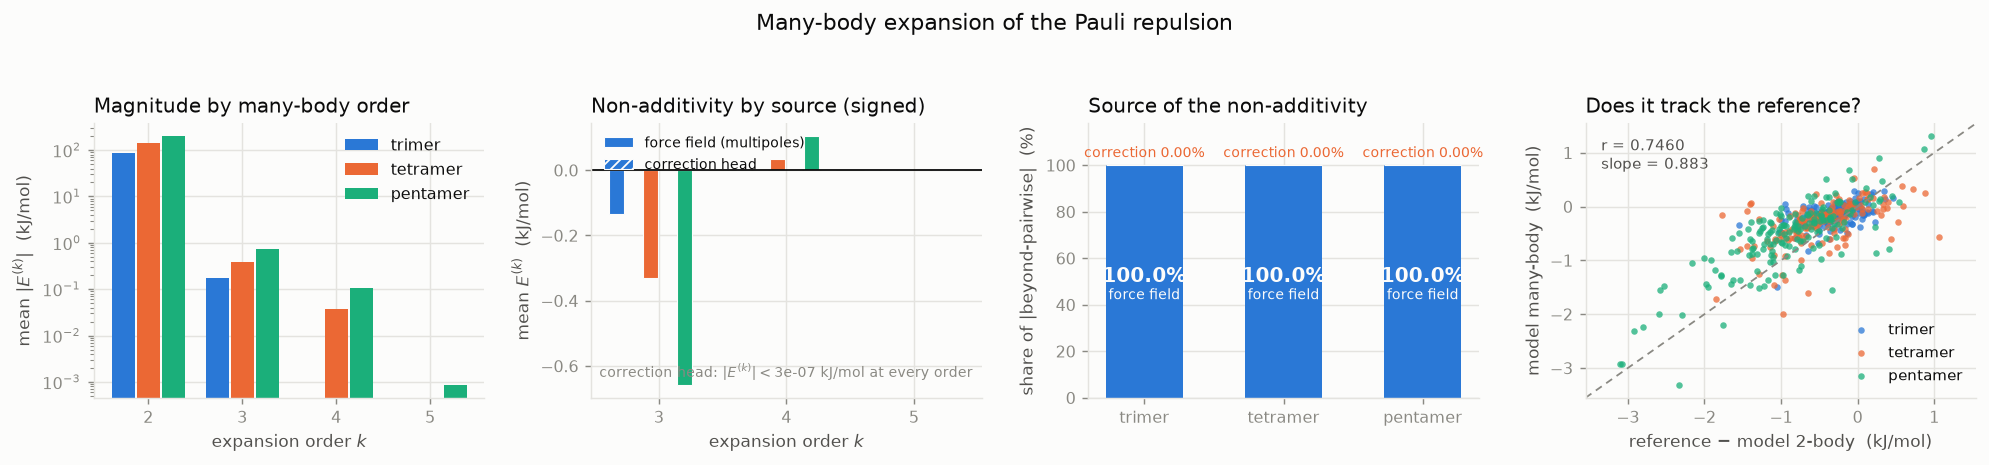

In [50]:
from pauli_analysis import many_body_table as pauli_mbe_table

pauli_mbe = pauli_mbe_table(pauli_model, datasets, 167, target=pauli_cfg.pauli.target)
_ = pp.many_body_panels(pauli_mbe)

In [51]:
print(f"many-body expansion over {len(pauli_mbe['total_total'])} strongly-interacting clusters:")
print("cluster   n     total     2-body    3-body    4-body    5-body   |MB|/|tot|")
for tag in ("w3", "w4", "w5"):
    m = pauli_mbe["tag"] == tag
    print(f"{tag:<10}{m.sum():<6}{pauli_mbe['total_total'][m].mean():<10.3f}"
          f"{pauli_mbe['total_two_body'][m].mean():<10.3f}{pauli_mbe['total_e3'][m].mean():<10.3f}"
          f"{pauli_mbe['total_e4'][m].mean():<10.3f}{pauli_mbe['total_e5'][m].mean():<10.3f}"
          f"{np.abs(pauli_mbe['total_many_body'][m] / pauli_mbe['total_total'][m]).mean()*100:.2f}%")

print("\nsource of the non-additivity (mean beyond-pairwise, kJ/mol):")
print(f"{'cluster':<10}{'force field':<14}{'correction head':<18}{'corr share'}")
for tag in ("w3", "w4", "w5"):
    m = pauli_mbe["tag"] == tag
    a = np.abs(pauli_mbe["ff_many_body"][m]).mean()
    b = np.abs(pauli_mbe["corr_many_body"][m]).mean()
    print(f"{tag:<10}{pauli_mbe['ff_many_body'][m].mean():<+14.4f}"
          f"{pauli_mbe['corr_many_body'][m].mean():<+18.3e}{b/max(a+b,1e-30)*100:.3f}%")

x = pauli_mbe["ref"] - pauli_mbe["total_two_body"]; y = pauli_mbe["total_many_body"]
print(f"\nmodel many-body vs (reference - model 2-body): "
      f"r = {np.corrcoef(y, x)[0,1]:.4f}, slope = {np.polyfit(y, x, 1)[0]:.3f}")

many-body expansion over 501 strongly-interacting clusters:
cluster   n     total     2-body    3-body    4-body    5-body   |MB|/|tot|
w3        167   87.721    87.857    -0.135    0.000     0.000     0.19%
w4        167   141.195   141.489   -0.330    0.036     0.000     0.24%
w5        167   202.097   202.651   -0.659    0.105     -0.000    0.31%

source of the non-additivity (mean beyond-pairwise, kJ/mol):
cluster   force field   correction head   corr share
w3        -0.1355       -7.497e-08        0.000%
w4        -0.2943       -1.958e-07        0.000%
w5        -0.5540       -4.689e-07        0.000%

model many-body vs (reference - model 2-body): r = 0.7460, slope = 0.883


Note the **sign contrast with dispersion**: the dispersion 3-body term came out positive
(repulsive, the Axilrod–Teller signature), while the Pauli 3-body is *negative* — repulsion
in a cluster is weaker than the sum of its pairs. The 4-body term flips sign again, as an
alternating expansion should.